Saving HistoryExchangeReport.csv to HistoryExchangeReport (8).csv
After dropna, shape: (55, 26)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.1037 - val_loss: 0.1388
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0226 - val_loss: 0.0279
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0086 - val_loss: 0.0051
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0107 - val_loss: 0.0053
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0092 - val_loss: 0.0150
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0057 - val_loss: 0.0288
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0048 - val_loss: 0.0307
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0041 - val_loss: 0.0244
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0031 - val_loss: 0.0158
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0030 - val_loss: 0.0118
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0022 - val_loss: 0.0130
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0020 - val_loss: 0.0174
Epoch 13/50

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Test RMSE: 65.26 VND


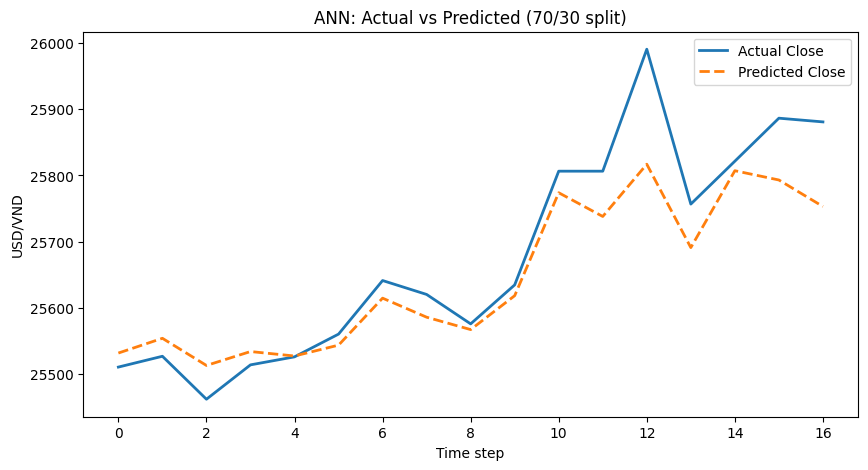

In [ ]:
# 1) Upload CSV
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

# 2) Đọc CSV, parse Date & bỏ dấu phẩy
import pandas as pd, numpy as np
df = pd.read_csv(fname, parse_dates=['Date'], thousands=',')

# 3) Chuẩn hóa cột Close
#    Nếu cột của bạn vẫn gọi là 'Rate', chuyển thành 'Close'
if 'Rate' in df.columns:
    df = df.rename(columns={'Rate':'Close'})

# 4) Sắp xếp theo ngày
df['Date'] = df['Date'].dt.normalize()
df = df.sort_values('Date').reset_index(drop=True)

# 5) Tính tất cả feature trong Python
df['Lag_1']   = df['Close'].shift(1)
df['Lag_3']   = df['Close'].shift(3)
df['Lag_5']   = df['Close'].shift(5)
df['Lag_7']   = df['Close'].shift(7)
df['MA_5']    = df['Close'].rolling(window=5).mean()
df['MA_20']   = df['Close'].rolling(window=20).mean()
df['EMA_10']  = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_20']  = df['Close'].ewm(span=20, adjust=False).mean()
df['ROC_1']   = df['Close'].pct_change(periods=1) * 100
df['ROC_3']   = df['Close'].pct_change(periods=3) * 100
df['STD_5']   = df['Close'].rolling(window=5).std()

# 6) Loại bỏ đông NaN do shift/rolling
df = df.dropna().reset_index(drop=True)
print("After dropna, shape:", df.shape)
df.head()

# 7) Chuẩn bị X, y
features = [
    'Lag_1','Lag_3','Lag_5','Lag_7',
    'MA_5','MA_20','EMA_10','EMA_20',
    'ROC_1','ROC_3','STD_5'
]
X = df[features].values
y = df['Close'].values.reshape(-1,1)

# 8) Scale dữ liệu
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler(); scaler_y = MinMaxScaler()
X_s = scaler_X.fit_transform(X)
y_s = scaler_y.fit_transform(y)

# 9) Split train/test = 70/30 (không shuffle)
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s, test_size=0.3, shuffle=False
)

# 10) Xây ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_tr.shape[1],)),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(1,   activation='linear')
])
model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 11) Train
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=16,
    validation_data=(X_te, y_te),
    callbacks=[es],
    verbose=1
)

# 12) Predict & Đánh giá
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

y_pred_s = model.predict(X_te)
y_pred   = scaler_y.inverse_transform(y_pred_s)
y_true   = scaler_y.inverse_transform(y_te)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Test RMSE: {rmse:.2f} VND")

# 13) Plot Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_true,   label='Actual Close', linewidth=2)
plt.plot(y_pred, '--', label='Predicted Close', linewidth=2)
plt.title("ANN: Actual vs Predicted (70/30 split)")
plt.xlabel("Time step")
plt.ylabel("USD/VND")
plt.legend()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


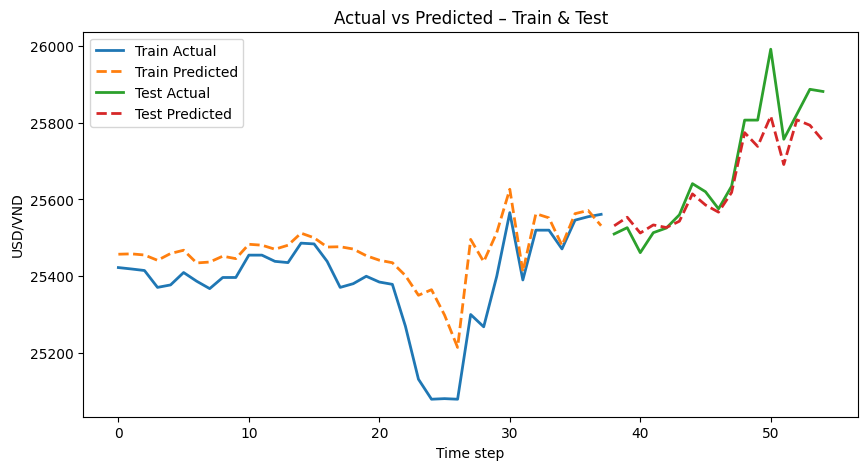

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 2.1) Dự đoán trên train & test (đã scale ngược về VND)
y_tr_pred = scaler_y.inverse_transform(model.predict(X_tr))
y_tr_true = scaler_y.inverse_transform(y_tr)

y_te_pred = scaler_y.inverse_transform(model.predict(X_te))
y_te_true = scaler_y.inverse_transform(y_te)

# 2.2) Tạo trục x liên tục cho train rồi nối tiếp test
x_tr = np.arange(len(y_tr_true))
x_te = np.arange(len(y_tr_true), len(y_tr_true) + len(y_te_true))

plt.figure(figsize=(10,5))
# Train
plt.plot(x_tr, y_tr_true,  label='Train Actual',   linewidth=2)
plt.plot(x_tr, y_tr_pred, '--', label='Train Predicted', linewidth=2)
# Test
plt.plot(x_te, y_te_true,  label='Test Actual',    linewidth=2)
plt.plot(x_te, y_te_pred, '--', label='Test Predicted',  linewidth=2)

plt.title('Actual vs Predicted – Train & Test')
plt.xlabel('Time step')
plt.ylabel('USD/VND')
plt.legend()
plt.show()

